In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/amirah1921/DailyDelhiDataset/refs/heads/main/DailyDelhiClimateTest.csv')
df.head()


,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [ ]:
X=df['meantemp']

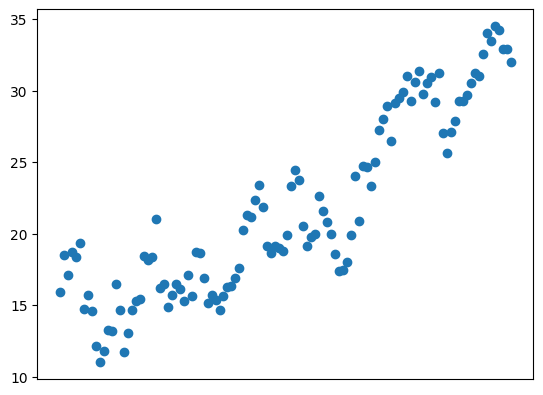

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x=df['date'],y=df['meantemp'])
plt.xticks([])
plt.show()

In [ ]:
data=df['meantemp'].tolist()

In [ ]:
def ewma(data,beta):
    s_prev=0
    output=[]
    if not data:
        return []
    else:
        for x in data:
            s_prev=beta* s_prev + (1-beta)*x
            output.append(s_prev)
    
    return output

ewma_data=ewma(data,beta=0.9)
            

In [ ]:
print(type(ewma_data))      
print(len(ewma_data))       



<class 'list'>
114


In [ ]:
ewma_data2=ewma(data=data,beta=0.5)
ewma_data3=ewma(data=data,beta=0.2)

In [ ]:
df["ewma_09"] = ewma_data
df["ewma_05"] = ewma_data2
df["ewma_02"] = ewma_data3
df

,date,meantemp,humidity,wind_speed,meanpressure,ewma,ewma_09,ewma_05,ewma_02
0,2017-01-01,15.913043,85.869565,2.743478,59.000000,1.591304,1.591304,7.956522,12.730435
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778,3.282174,3.282174,13.228261,17.346087
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333,4.665068,4.665068,15.169686,17.158106
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000,6.068561,6.068561,16.934843,18.391621
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333,7.300594,7.300594,17.661866,18.389435
...,...,...,...,...,...,...,...,...,...
109,2017-04-20,34.500000,27.500000,5.562500,998.625000,30.639882,30.639882,33.833047,34.305969
110,2017-04-21,34.250000,39.375000,6.962500,999.875000,31.000894,31.000894,34.041523,34.261194
111,2017-04-22,32.900000,40.900000,8.890000,1001.600000,31.190805,31.190805,33.470762,33.172239
112,2017-04-23,32.875000,27.500000,9.962500,1002.125000,31.359224,31.359224,33.172881,32.934448


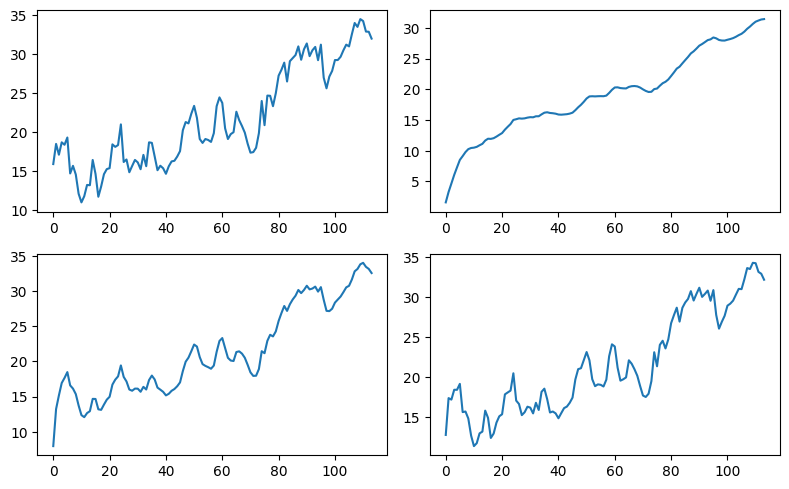

In [ ]:
plots=["meantemp","ewma_09","ewma_05","ewma_02"]
titles=["No EWMA","EWMA(beta=0.9)","EWMA(beta=0.5)","EWMA(beta=0.2)"]
fig,axs=plt.subplots(2,2,figsize=(8,5))
axs=axs.flatten()
for i,ax in enumerate(axs):
    ax.plot(df[plots[i]])
    ax.xticks=([])
    ax.set_ylabel=titles[i]

plt.tight_layout()
plt.show()